In [6]:
from torchvision import transforms
from torchvision.models.vision_transformer import EncoderBlock
from torch.utils.data import DataLoader
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import pandas as pd
import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
CROP_SIZE = 207
INPUT_SIZE = 64
N_WORKERS = 0
RUN = False

DEVICE

device(type='cpu')

In [7]:
#make a class to transform and organize data
class GalaxyDataset(Dataset):
    def __init__(self, image_paths, labels_csv, transform=None, cache_path=None):
        self.transform = transform

        if cache_path and Path(cache_path).exists():
            cache = torch.load(cache_path, weights_only=False)
            self.images = cache['images']
            self.galaxy_ids = cache['galaxy_ids']
            self.labels_df = cache['labels_df']
            
        else:
            pre = transforms.Compose([
                transforms.CenterCrop(CROP_SIZE),
                transforms.Resize(INPUT_SIZE),
                transforms.ToTensor(),
            ])
            self.galaxy_ids = [int(p.stem) for p in image_paths]
            self.images = torch.stack([pre(Image.open(p).convert("RGB")) for p in tqdm.tqdm(image_paths)]).half()
            self.labels_df = pd.read_csv(labels_csv, index_col="GalaxyID")

            if cache_path:
                torch.save({'images': self.images,
                            'galaxy_ids': self.galaxy_ids,
                            'labels_df': self.labels_df},
                            cache_path)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        label_values = self.labels_df.loc[self.galaxy_ids[idx]].values
        label = torch.tensor(label_values, dtype=torch.float32, device=img.device)

        return img, label
    
    def __len__(self):
        return len(self.images)

In [8]:
data_dir   = Path(r"C:\Users\harty\Code\Galaxy-Classifier\Data\images_training_rev1")
labels_csv = r"C:\Users\harty\Code\Galaxy-Classifier\Data\training_solutions_rev1.csv"
all_paths  = sorted(data_dir.glob("*.jpg"))

indices = torch.randperm(len(all_paths), generator=torch.Generator().manual_seed(42))
n_val   = int(len(all_paths) * 0.1)

train_paths = [all_paths[i] for i in indices[n_val:]]
val_paths   = [all_paths[i] for i in indices[:n_val]]

In [9]:
# load training data to compute average and stdev
train_set = GalaxyDataset(train_paths, labels_csv, transform=None, cache_path='train_set.pth')

# get averages and stdevs for each color in the image
train_mean = train_set.images.mean(dim=[0, 2, 3]).tolist()
train_std = train_set.images.std(dim=[0, 2, 3]).tolist()

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(0, 360)),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# use training means and stds to treat val data as 'unseen'
# do not randomly rotate the validation data for the same reason
val_transform = transforms.Compose([
    transforms.Normalize(mean=train_mean, std=train_std),
])

train_set = GalaxyDataset(train_paths, labels_csv,
                          transform=train_transform,
                          cache_path='train_set.pth')
val_set = GalaxyDataset(val_paths, labels_csv,
                        transform=val_transform,
                        cache_path='val_set.pth')

train_set.images = train_set.images.to(DEVICE)
val_set.images = val_set.images.to(DEVICE)

★ Mosaic Grid Updated: Left column is pixelated and cropped; Right column is wide-field original.


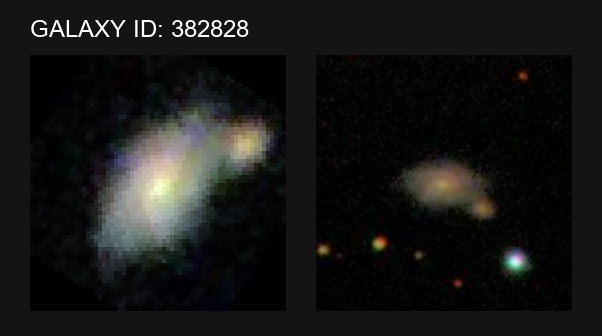

In [12]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import numpy as np

n_disp = 1

# --- HIGH RESOLUTION CONFIGURATION ---
img_w, img_h = 256, 256  

mosaic_w = (img_w * 2) + 90  
row_total_h = img_h + 80     
mosaic_h = row_total_h * n_disp

mosaic_canvas = Image.new("RGB", (mosaic_w, mosaic_h), (20, 20, 20))
draw = ImageDraw.Draw(mosaic_canvas)

try:
    font = ImageFont.truetype("arial.ttf", 24)
except IOError:
    font = ImageFont.load_default()

for idx in range(n_disp):
    row_start_y = idx * row_total_h
    
    # Fetch active tensor data and matching file pathway tracking references
    img_tensor, label = train_set[idx]
    galaxy_id = train_set.galaxy_ids[idx]
    actual_file_path = train_paths[idx] # <-- Added to find the real file path
    
    # -------------------------------------------------------------------------
    # 1. DRAW TEXT: Header spanning the top width of the row
    # -------------------------------------------------------------------------
    text_str = f"GALAXY ID: {galaxy_id}"
    draw.text((30, row_start_y + 15), text_str, fill=(255, 255, 255), font=font)
    
    image_y = row_start_y + 55
    
    # -------------------------------------------------------------------------
    # 2. GENERATE LEFT IMAGE: Processed (64x64, Rotated, and Pixelated)
    # -------------------------------------------------------------------------
    img_numpy = img_tensor.permute(1, 2, 0).float().cpu().numpy()
    img_min, img_max = img_numpy.min(), img_numpy.max()
    img_scaled = (img_numpy - img_min) / (img_max - img_min + 1e-8)
    
    left_bytes = (img_scaled * 255).astype(np.uint8)
    left_pil = Image.fromarray(left_bytes)
    
    # Preserves blocky structure
    left_pil_resized = left_pil.resize((img_w, img_h), Image.Resampling.NEAREST)
    mosaic_canvas.paste(left_pil_resized, (30, image_y))
    
    # -------------------------------------------------------------------------
    # 3. GENERATE RIGHT IMAGE: True Uncropped Original JPG File from Disk
    # -------------------------------------------------------------------------
    # FIX: Read the untouched raw image straight from storage, bypassing the cache array entirely
    if actual_file_path.exists():
        right_pil = Image.open(actual_file_path).convert("RGB")
        
        # Smoothly scale the entire original field down into the column cell block
        right_pil_resized = right_pil.resize((img_w, img_h), Image.Resampling.LANCZOS)
        mosaic_canvas.paste(right_pil_resized, (img_w + 60, image_y))
    else:
        # Visual error box fallback 
        error_box = Image.new("RGB", (img_w, img_h), (50, 20, 20))
        mosaic_canvas.paste(error_box, (img_w + 60, image_y))

# -------------------------------------------------------------------------
# 4. DISPLAY THE COHESIVE CANVAS SHEET
# -------------------------------------------------------------------------
print("★ Mosaic Grid Updated: Left column is pixelated and cropped; Right column is wide-field original.")
display(mosaic_canvas)
